In [2]:
import numpy as np
import pickle
import pandas as pd
import datetime, time
import math
import matplotlib.pyplot as plt

**Understanding the dataset**

In [4]:
df = pd.read_csv(f"BTCUSDT-15m-data.csv")
print(df)

                  timestamp      open_time       open       high        low  \
0       2017-08-17 04:00:00  1502942400000    4261.48    4280.56    4261.48   
1       2017-08-17 04:15:00  1502943300000    4261.48    4270.41    4261.32   
2       2017-08-17 04:30:00  1502944200000    4280.00    4310.07    4267.99   
3       2017-08-17 04:45:00  1502945100000    4310.07    4313.62    4291.37   
4       2017-08-17 05:00:00  1502946000000    4308.83    4328.69    4304.31   
...                     ...            ...        ...        ...        ...   
275995  2025-07-07 00:00:00  1751846400000  109203.85  109273.07  109103.19   
275996  2025-07-07 00:15:00  1751847300000  109273.07  109288.02  108972.69   
275997  2025-07-07 00:30:00  1751848200000  109004.81  109037.82  108829.17   
275998  2025-07-07 00:45:00  1751849100000  108847.17  108922.00  108800.01   
275999  2025-07-07 01:00:00  1751850000000  108823.07  108823.08  108679.75   

            close     volume     close_time      qu

**Visualize data**

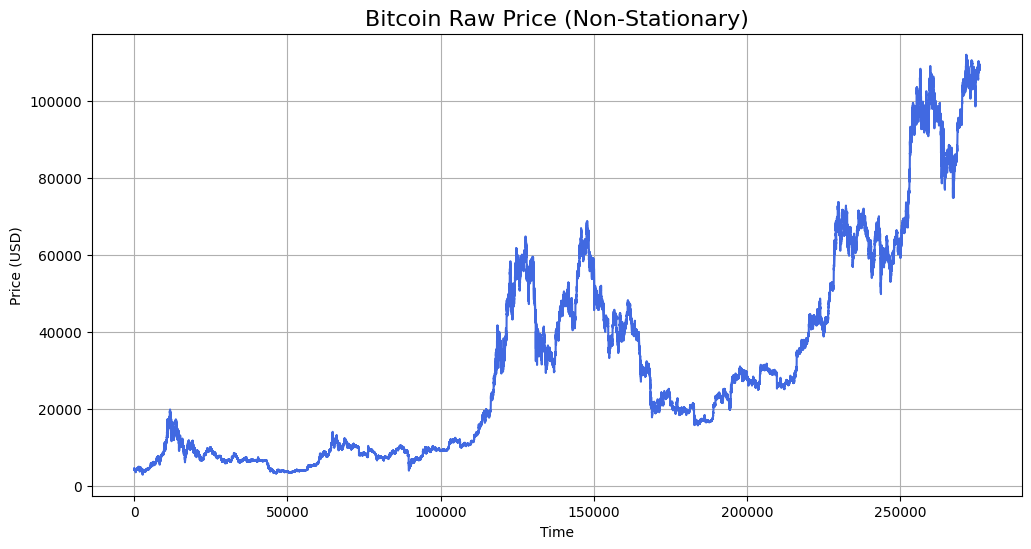

In [5]:
prices = df['close']

plt.figure(figsize=(12, 6))
plt.plot(prices, color='royalblue')
plt.title('Bitcoin Raw Price (Non-Stationary)', fontsize=16)
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.grid()
plt.show()

**Visualize how mean changes over time**

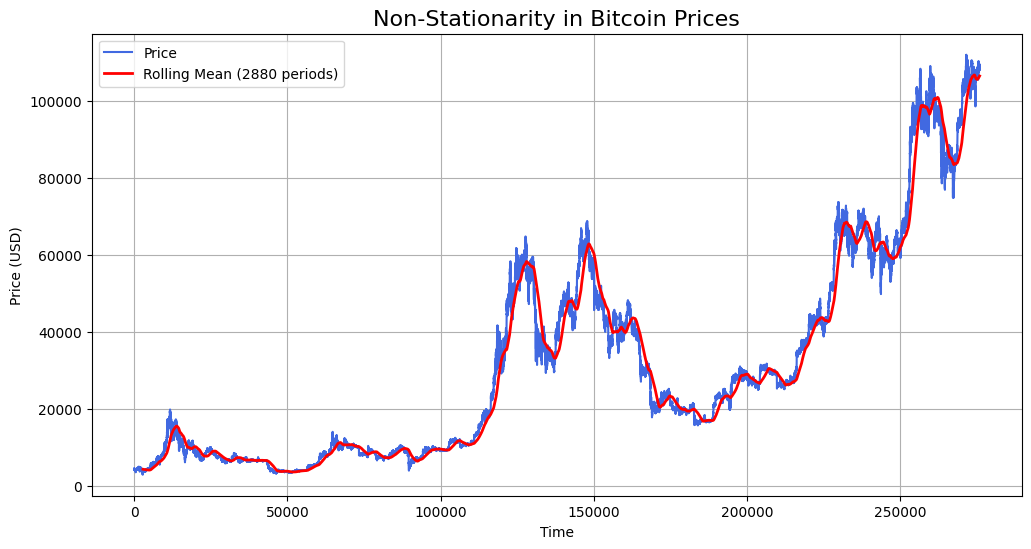

In [6]:
window = 96 * 30

moving_averages = []

for i in range(len(prices)):
    if i < window - 1:
        moving_averages.append(np.nan)
    else:
        window_data = prices[i - window + 1:i + 1]
        mean = np.mean(window_data)
        moving_averages.append(mean)

plt.figure(figsize=(12, 6))
plt.plot(prices, color='royalblue', label='Price')
plt.plot(moving_averages, color='red', linewidth=2, label=f'Rolling Mean ({window} periods)')
plt.title('Non-Stationarity in Bitcoin Prices', fontsize=16)
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()


**Visualize how variance changes over time**

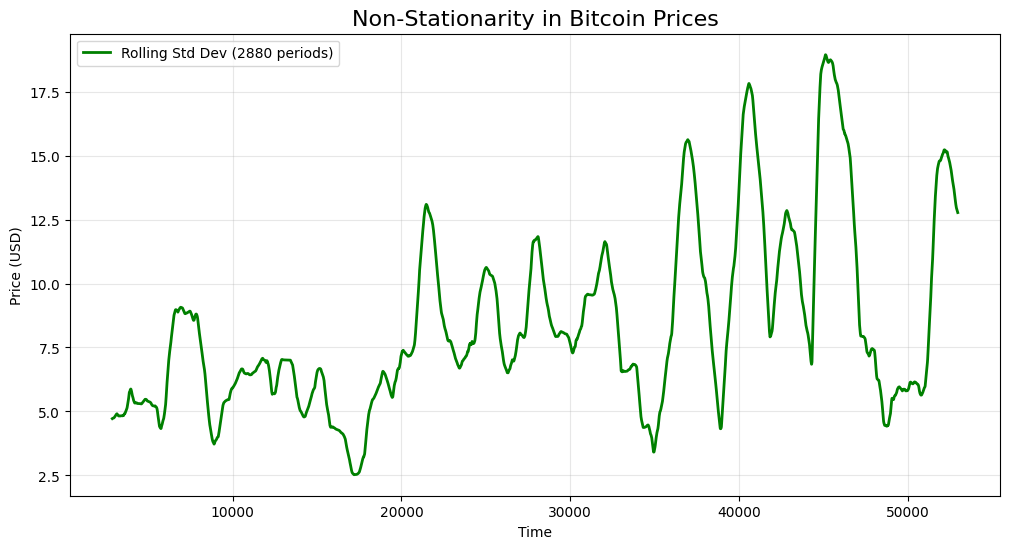

In [ ]:
window = 96 * 30

moving_std = []

for i in range(len(prices)):
    if i < window - 1:
        moving_std.append(np.nan)
    else:
        window_data = prices[i - window + 1:i + 1]
        std = np.std(window_data, ddof=1)
        moving_std.append(std)

plt.figure(figsize=(12, 6))
plt.plot(moving_std, color='green', linewidth=2, label=f'Rolling Std Dev ({window} periods)')
plt.title('Non-Stationarity in Bitcoin Prices', fontsize=16)
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**Stationary transformation**

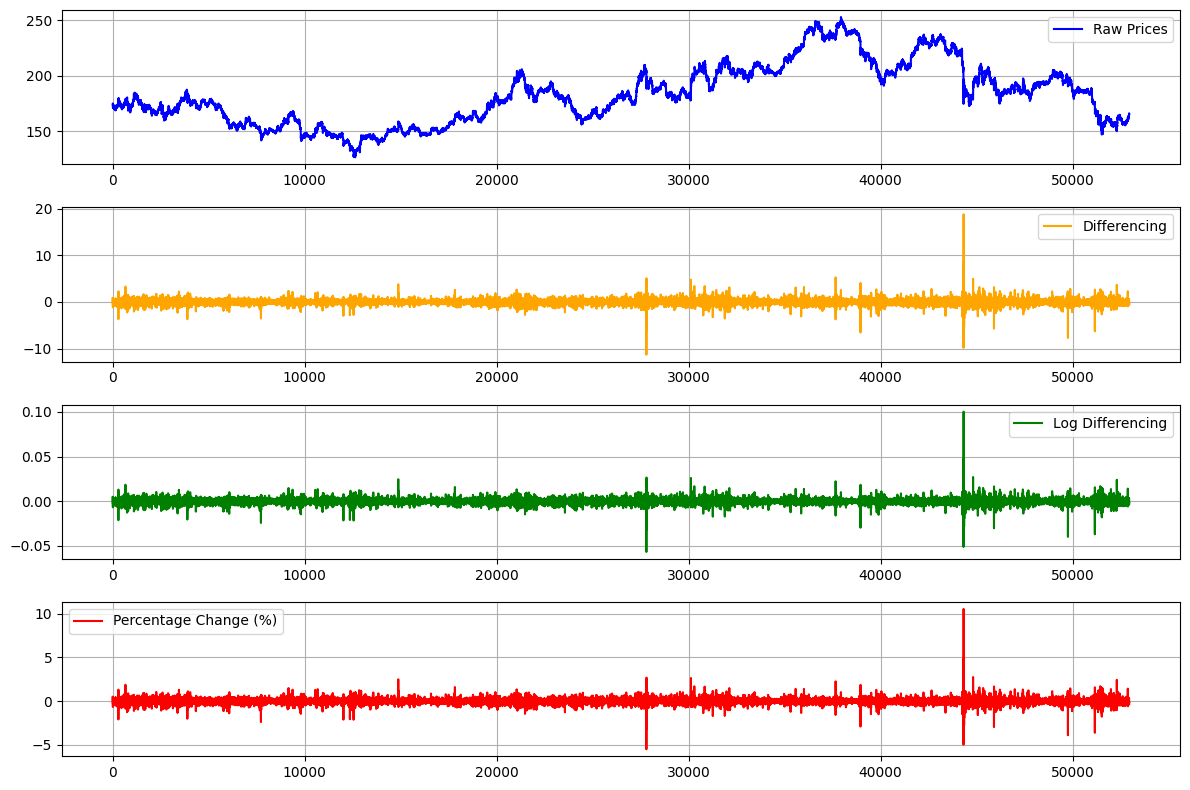

In [ ]:
# Differencing
diff_prices = [np.nan]
for i in range(1, len(prices)):
    diff_prices.append(prices[i] - prices[i-1])

# -----------------------------
# Approach 1: Log Differencing
# -----------------------------
log_prices = np.log(prices)
log_diff_prices = [np.nan]
for i in range(1, len(log_prices)):
    log_diff_prices.append(log_prices[i] - log_prices[i-1])

# -----------------------------
# Approach 2: Percentage Change
# -----------------------------
pct_change_prices = [np.nan]
for i in range(1, len(prices)):
    pct_change_prices.append(((prices[i] - prices[i-1]) / prices[i-1]) * 100)

# -----------------------------
# Plot all
# -----------------------------
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(prices, label="Raw Prices", color="blue")
plt.legend()
plt.grid()

plt.subplot(4, 1, 2)
plt.plot(diff_prices, label="Differencing", color="orange")
plt.legend()
plt.grid()

plt.subplot(4, 1, 3)
plt.plot(log_diff_prices, label="Log Differencing", color="green")
plt.legend()
plt.grid()

plt.subplot(4, 1, 4)
plt.plot(pct_change_prices, label="Percentage Change (%)", color="red")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()